# File for dimensionality reduction and clustering

#### Importing packages:

In [2]:
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
import pandas as pd
import os
import numpy as np
import umap
from sklearn.datasets import fetch_openml
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster
from sklearn import manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

#### Getting data imported:

In [26]:
#Using this to get the photo names:
image_example_path = "images"
image_file_names = [f for f in listdir(image_example_path) if isfile(join(image_example_path, f))]

In [27]:
#printed so it´s not only me that can see it(change path to the one that works for you if you want the code to work)
print(image_file_names)

['0_left.webp', '0_right.webp', '1_left.webp', '1_right.webp', '2_left.webp', '2_right.webp', '3_left.webp', '3_right.webp', '4_left.webp', '4_right.webp', '5_left.webp', '5_right.webp', '6_left.webp', '6_right.webp', '7_left.webp', '7_right.webp', '8_left.webp', '8_right.webp', '9_left.webp', '9_right.webp']


In [9]:
unique_path = r"../data\grand_scraper_folder\unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)

In [35]:
test = "2025-04-21"

In [79]:
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]
#unique_images = [unique_dataframe["occurrences"][i][11:17] for i in range(len(unique_dataframe["occurrences"]))]
unique_entries

['2025-04-20:0_left.webp',
 '2025-04-20:0_right.webp',
 '2025-04-20:1_left.webp',
 '2025-04-20:1_right.webp',
 '2025-04-20:2_left.webp',
 '2025-04-20:2_right.webp',
 '2025-04-20:3_left.webp',
 '2025-04-20:3_right.webp',
 '2025-04-20:4_left.webp',
 '2025-04-20:4_right.webp',
 '2025-04-20:5_left.webp',
 '2025-04-20:5_right.webp',
 '2025-04-20:6_left.webp',
 '2025-04-20:6_right.webp',
 '2025-04-20:7_left.webp',
 '2025-04-20:7_right.webp',
 '2025-04-20:8_left.webp',
 '2025-04-20:8_right.webp',
 '2025-04-20:9_left.webp',
 '2025-04-20:9_right.webp',
 '2025-04-21:0_left.webp',
 '2025-04-21:0_right.webp',
 '2025-04-21:1_left.webp',
 '2025-04-21:1_right.webp',
 '2025-04-21:2_left.webp',
 '2025-04-21:2_right.webp',
 '2025-04-21:3_left.webp',
 '2025-04-21:3_right.webp',
 '2025-04-21:4_left.webp',
 '2025-04-21:4_right.webp',
 '2025-04-21:5_left.webp',
 '2025-04-21:5_right.webp',
 '2025-04-21:6_left.webp',
 '2025-04-21:6_right.webp',
 '2025-04-21:7_left.webp',
 '2025-04-21:7_right.webp',
 '2025-04-

In [91]:
superstuff = unique_dataframe.loc[unique_dataframe["club"] == "Super Cup Final"]
superstuff

,title,subtitle,price,rating,image_hash,occurrences,club,country,year,elo
4,Katsu chicken curry,NaN,5.5,91.2,972c80a83ed064937093e776361e83b6,2025-04-20:2_left | 2025-06-01:7_right | 2025-...,Super Cup Final,JPN,2023,581.662894


In [87]:
unique_dataframe

,title,subtitle,price,rating,image_hash,occurrences,club,country,year,elo
0,Hot dog in a waffle,NaN,2.60,25.80,16e31e839190d590eaf12295d90e8e21,2025-04-20:0_left | 2025-04-29:8_right | 2025-...,Fredrikstad FK,NOR,2022,183.859911
1,Chicharrones,Fried pork belly with guac and chimichurri,9.50,90.60,e2bc591910ad1e91cfe9a3f55c90be74,2025-04-20:0_right,Eden Park,NZL,2023,647.998796
2,Sánguche de potito,Cows rectum sandwich,2.80,32.50,0cc3106abed465439d5dfe7fb0f7815e,2025-04-20:1_left | 2025-05-18:2_right | 2025-...,Universidad de Chile,CHI,2022,203.936143
3,Turkey schnitzel,NaN,3.40,81.00,e9db7022b5a276a790d0b28f7e8fd77b,2025-04-20:1_right | 2025-08-18:3_right | 2025...,Borussia Monchengladbach,GER,2022,368.017564
4,Katsu chicken curry,NaN,5.50,91.20,972c80a83ed064937093e776361e83b6,2025-04-20:2_left | 2025-06-01:7_right | 2025-...,Super Cup Final,JPN,2023,581.662894
...,...,...,...,...,...,...,...,...,...,...
4583,Chicken club sandwich,NaN,5.20,14.94,ef1e9cd7290019321e0522eb0895da52,2026-05-19:7_right,Parc des Princes,FRA,2023,191.669698
4584,Polish dog,NaN,3.40,28.71,246124c2a95bad3e207c7c2c575fd1a3,2026-05-19:8_left,Ferry to Canada,USA,2026,227.266694
4585,American hot dog,"Pickles, fried onions, mustard, ketchup, 0,5l ...",5.50,55.95,0c18da3fa2b4aa0329f848b83325e004,2026-05-19:8_right,Śląsk Wrocław,POL,2026,434.159535
4586,Strawberry daiquiri / pina colada mix,NaN,16.45,52.41,1b7bad06896cd389479b0659f810aff7,2026-05-19:9_left,New York Red Bulls,USA,2022,430.181481


In [34]:
unique_dataframe["occurrences"][1][11:17] in image_file_names[0]

False

In [57]:
result = any(test in word for word in unique_dates)
result

True

In [66]:
any(image_file_names[0] in word for word in unique_dates)

False

In [92]:
#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []

#Next, a list for the metadata i want(for now, at least. there´s certainly going to be a better way of doing this later):
metadata_image_clustering = []


#Folder with folders of images:
base_folder = r"../data\scrandle_padded_low_res_data"
#Meta data folders(yes, a bit inefficient. CHANGE LATER):
meta_folder = r"../data\scrandle_padded_low_res_data"
current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    meta_date_path = os.path.join(meta_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    image_Data_low_res.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

    if current_folder != date:
        current_folder = date
        meta_path = os.path.join(date_path, "meta.csv")
        meta_intermediate = pd.read_csv(meta_path)
    entry_row = meta_intermediate.loc[meta_intermediate["image_name"] == image_placement]
    metadata_image_clustering.append({
                "price": entry_row["price"],
                "rating": entry_row["rating"],
                "year": entry_row["year"],
                "date": entry_row["date"],
                "image_name": entry_row["image_name"],
                "title": entry_row["title"],
                "subtitle": entry_row["subtitle"],
                "club": entry_row["club"],
                "country": entry_row["country"],
            })

Processing 2025-04-20:0_left.webp
Processing 2025-04-20:0_right.webp
Processing 2025-04-20:1_left.webp
Processing 2025-04-20:1_right.webp
Processing 2025-04-20:2_left.webp
Processing 2025-04-20:2_right.webp
Processing 2025-04-20:3_left.webp
Processing 2025-04-20:3_right.webp
Processing 2025-04-20:4_left.webp
Processing 2025-04-20:4_right.webp
Processing 2025-04-20:5_left.webp
Processing 2025-04-20:5_right.webp
Processing 2025-04-20:6_left.webp
Processing 2025-04-20:6_right.webp
Processing 2025-04-20:7_left.webp
Processing 2025-04-20:7_right.webp
Processing 2025-04-20:8_left.webp
Processing 2025-04-20:8_right.webp
Processing 2025-04-20:9_left.webp
Processing 2025-04-20:9_right.webp
Processing 2025-04-21:0_left.webp
Processing 2025-04-21:0_right.webp
Processing 2025-04-21:1_left.webp
Processing 2025-04-21:1_right.webp
Processing 2025-04-21:2_left.webp
Processing 2025-04-21:2_right.webp
Processing 2025-04-21:3_left.webp
Processing 2025-04-21:3_right.webp
Processing 2025-04-21:4_left.webp


In [93]:
#Now, we want to convert the images to a gigantic pandas dataframe, where each pixel of the image corresponds to 3 variables(R, G, and B)
#First, let´s remove the extra meta data to only have the pictures(likely a better way. Am very open to suggestions):
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])

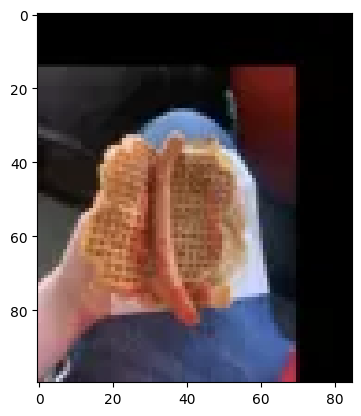

In [96]:
plt.imshow(image_only_low_res[0])

In [36]:
#Now, we use this list to make a matrix, which we´ll then convert to a pandas dataframe
#NOTE: triple loop. Can likely be optimized, and i´m, again, very open to suggestions...
image_pixels = []
for k in range(len(image_only_low_res)):
    image_RGB = []
    for i in range(100):
        for j in range(3):
            image_RGB.append(image_only_low_res[k][i].T[j])
    image_RGB = np.hstack(image_RGB)
    image_pixels.append(image_RGB)
image_pixels = np.vstack(image_pixels)
image_pixel_dataframe = pd.DataFrame(image_pixels)

In [37]:
#This is here so you can see the format(without having to run it all and change the directories):
image_pixel_dataframe

,0,1,2,3,4,5,6,7,8,9,...,25490,25491,25492,25493,25494,25495,25496,25497,25498,25499
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,72,63,83,72,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,2,1,1,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7895,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7896,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7897,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7898,0,0,0,0,0,0,0,0,0,0,...,34,13,11,7,5,84,63,50,38,25


In [38]:
#Now to add the remaining variables that are not pixels.
#First, lets create them(through loops, sorry):
image_years = []
image_pricing = []
image_rating = []
image_placement = []
image_title = []
image_subtitle = []
image_club = []
image_country = []
for i in range(len(metadata_image_clustering)):
    image_years += list(metadata_image_clustering[i]["year"])
    image_pricing += list(metadata_image_clustering[i]["price"])
    image_rating += list(metadata_image_clustering[i]["rating"])
    image_placement += list(metadata_image_clustering[i]["date"] + "___" + metadata_image_clustering[i]["image_name"])
    image_title += list(metadata_image_clustering[i]["title"])
    image_subtitle += list(metadata_image_clustering[i]["subtitle"])
    image_club += list(metadata_image_clustering[i]["club"])
    image_country += list(metadata_image_clustering[i]["country"])
    

In [39]:
image_placement

['2025-04-20___0_left.webp',
 '2025-04-20___0_right.webp',
 '2025-04-20___1_left.webp',
 '2025-04-20___1_right.webp',
 '2025-04-20___2_left.webp',
 '2025-04-20___2_right.webp',
 '2025-04-20___3_left.webp',
 '2025-04-20___3_right.webp',
 '2025-04-20___4_left.webp',
 '2025-04-20___4_right.webp',
 '2025-04-20___5_left.webp',
 '2025-04-20___5_right.webp',
 '2025-04-20___6_left.webp',
 '2025-04-20___6_right.webp',
 '2025-04-20___7_left.webp',
 '2025-04-20___7_right.webp',
 '2025-04-20___8_left.webp',
 '2025-04-20___8_right.webp',
 '2025-04-20___9_left.webp',
 '2025-04-20___9_right.webp',
 '2025-04-21___0_left.webp',
 '2025-04-21___0_right.webp',
 '2025-04-21___1_left.webp',
 '2025-04-21___1_right.webp',
 '2025-04-21___2_left.webp',
 '2025-04-21___2_right.webp',
 '2025-04-21___3_left.webp',
 '2025-04-21___3_right.webp',
 '2025-04-21___4_left.webp',
 '2025-04-21___4_right.webp',
 '2025-04-21___5_left.webp',
 '2025-04-21___5_right.webp',
 '2025-04-21___6_left.webp',
 '2025-04-21___6_right.webp

In [40]:
#before moving on, i have an announcement:
#WE HAVE NaN VALUES IN OUR PRICING DATA!!!!(361 of them, to be precise, though some may be repeat NaN´s)
nan_nonsense = 0
for i in range(len(image_pricing)):
    if np.isnan(np.array(image_pricing))[i] == np.True_:
        nan_nonsense += 1
nan_nonsense

346

In [41]:
#Adding the extra columns:
image_pixel_dataframe["price"] = image_pricing
image_pixel_dataframe["rating"] = image_rating
image_pixel_dataframe["year"] = image_years
image_pixel_dataframe["image_placement"] = image_placement
image_pixel_dataframe["title"] = image_title
image_pixel_dataframe["subtitle"] = image_subtitle
image_pixel_dataframe["club"] = image_club
image_pixel_dataframe["country"] = image_country

In [42]:
#Dropping out the 361 NaN values for now(considering the size of the dataset, it feels appropriate)
image_pixel_dataframe_no_NaN = image_pixel_dataframe.dropna()


In [43]:
#Getting dataframe vars, and getting array variant to check with later:
vars_image_pixel_dataframe = image_pixel_dataframe_no_NaN.columns
numpy_image_pixel_comp = np.array(image_pixel_dataframe_no_NaN)


In [44]:
image_pixel_dataframe_no_NaN

,0,1,2,3,4,5,6,7,8,9,...,25498,25499,price,rating,year,image_placement,title,subtitle,club,country
0,0,0,0,0,0,0,0,0,0,0,...,0,0,2.60,25.80,2022,2025-04-20___0_left.webp,533,2,243,34
1,0,0,0,0,0,0,0,0,0,0,...,0,0,9.50,90.60,2023,2025-04-20___0_right.webp,1508,3615,616,56
2,0,0,0,0,0,0,0,0,0,0,...,0,0,2.80,32.50,2022,2025-04-20___1_left.webp,668,735,763,530
3,0,0,0,0,0,0,0,0,0,0,...,0,0,3.40,81.00,2022,2025-04-20___1_right.webp,669,2,208,6
4,0,0,0,0,0,0,0,0,0,0,...,0,0,5.50,91.20,2023,2025-04-20___2_left.webp,433,2,994,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7895,0,0,0,0,0,0,0,0,0,0,...,0,0,5.20,14.94,2023,2026-05-19___7_right.webp,1233,2,1073,21
7896,0,0,0,0,0,0,0,0,0,0,...,0,0,3.40,28.71,2026,2026-05-19___8_left.webp,3612,2,4395,4
7897,0,0,0,0,0,0,0,0,0,0,...,0,0,5.50,55.95,2026,2026-05-19___8_right.webp,3613,3985,4396,18
7898,0,0,0,0,0,0,0,0,0,0,...,38,25,16.45,52.41,2022,2026-05-19___9_left.webp,3614,2,648,4


#### Dimensionality reduction using UMAP

In [56]:
#Normalizing the data:
image_pixel_dataframe_norm = pd.DataFrame(preprocessing.normalize(
    image_pixel_dataframe_no_NaN[vars_image_pixel_dataframe[(vars_image_pixel_dataframe != 'image_placement')]]))

In [57]:
#Getting the 2D projection of data(seperate from plotting, as umap is actually the most time intensive function in this entire doc.)
#WARNING: Takes a good 6-8 minutes to run!!!
umap_projector = umap.UMAP(n_components=2, n_neighbors=50, random_state=42).fit(image_pixel_dataframe_norm)
umap_2D_projection = umap_projector.fit_transform(image_pixel_dataframe_norm)

c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


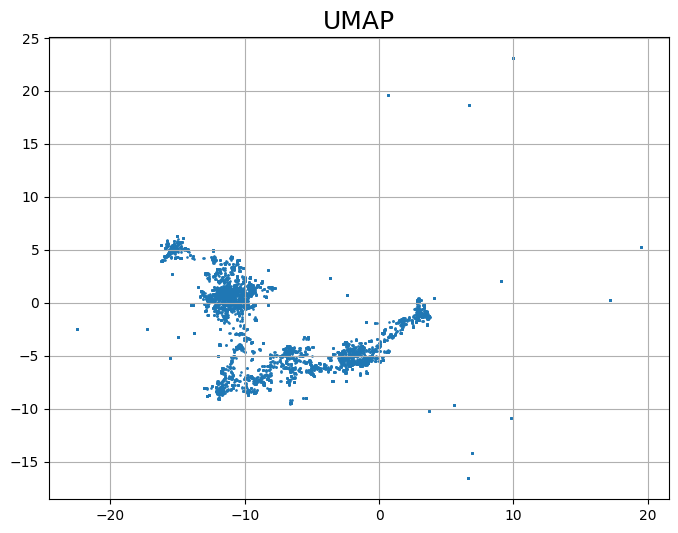

In [58]:
#Plotting the projection of data:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=0.8)
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

#### Clustering Algorithm results:

##### KMeans

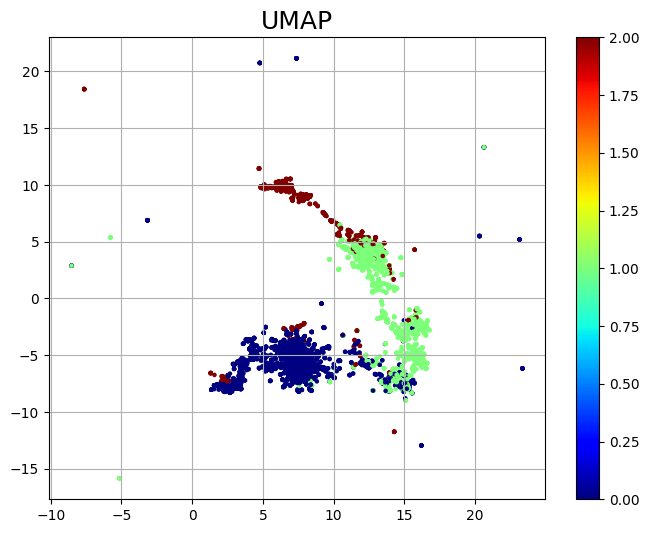

In [87]:
#KMeans as a simple version first:
kmeans = cluster.KMeans(n_clusters=3, n_init="auto").fit(image_pixel_dataframe_norm)
colours = kmeans.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5, c = colours, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

(10.0, 70.0)

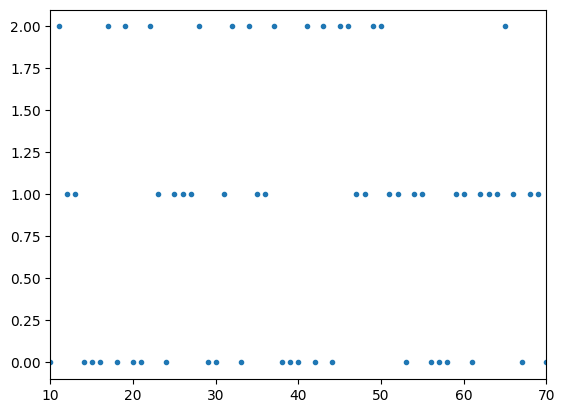

In [68]:
#Plotting the labels to check for patterns:
plt.plot(kmeans.labels_, ".")
plt.xlim(10, 70)

##### DBSCAN

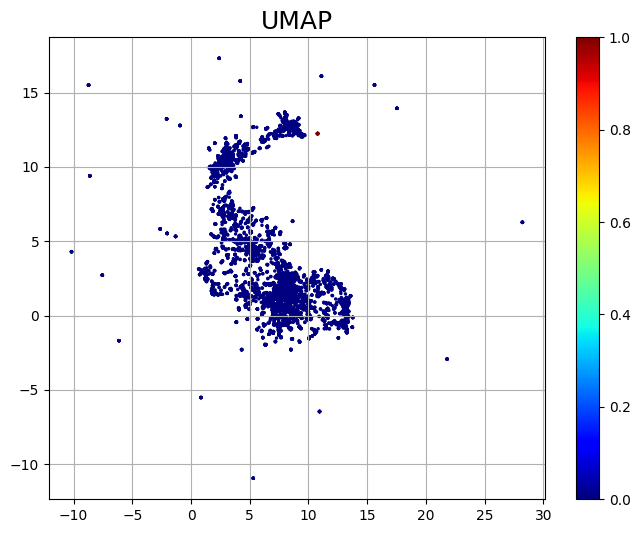

In [69]:
dbscan = cluster.DBSCAN(eps=0.5, min_samples=15).fit(image_pixel_dataframe_norm)
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

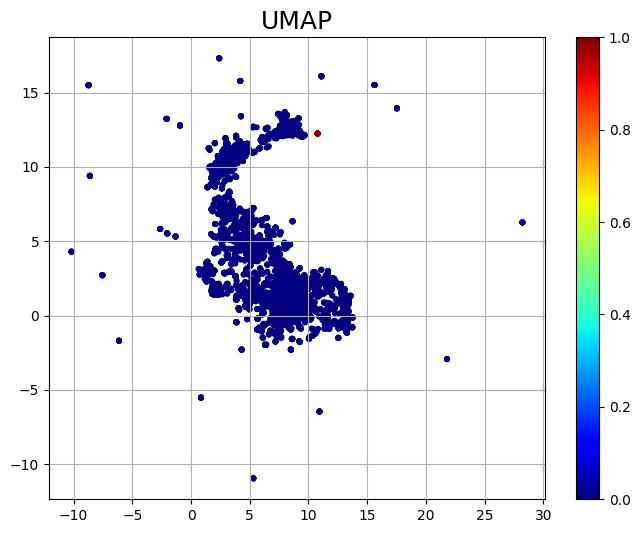

In [70]:
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=10.8, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

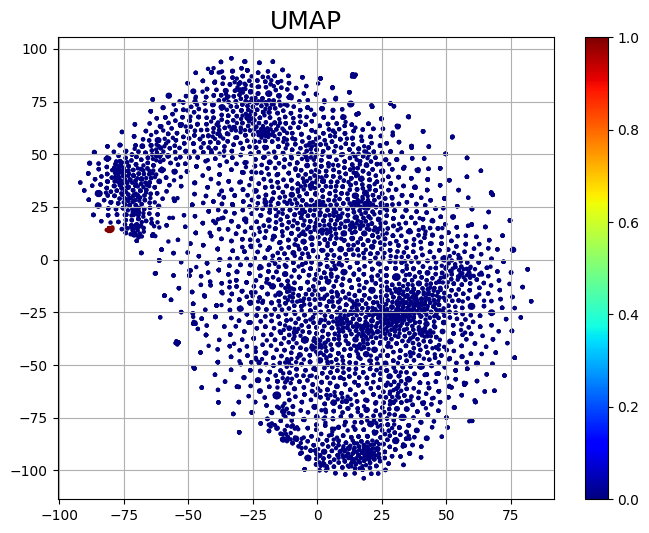

In [ ]:
colours_db = dbscan.labels_+1
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=10.8, c = colours_db, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

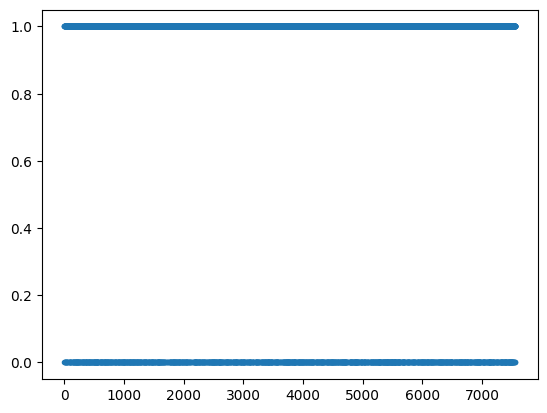

In [23]:
plt.plot(dbscan.labels_+1, ".")

#### Spectral clustering

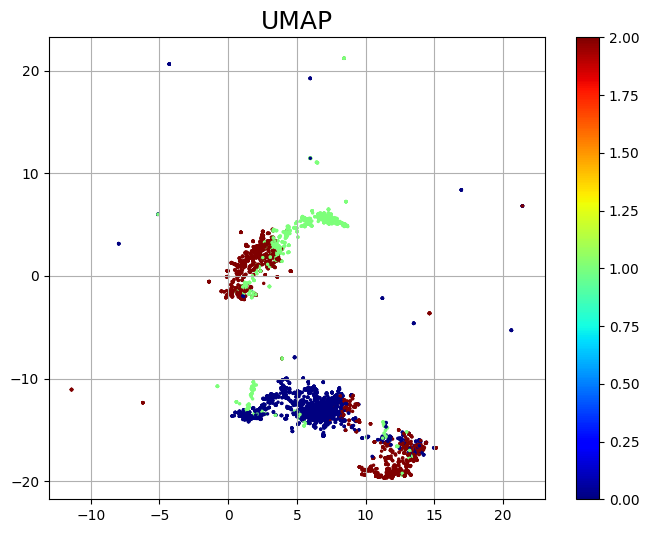

In [24]:
spectral = cluster.SpectralClustering(assign_labels="discretize", n_clusters=3, random_state=42).fit(image_pixel_dataframe_norm)
colours_spec = spectral.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=2.2, c = colours_spec, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

#### Optics

In [25]:
optics = cluster.OPTICS(min_samples=5).fit(image_pixel_dataframe_norm[:1000])
colours_opt = optics.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0][:1000], umap_2D_projection[:, 1][:1000], s=2.2, c = colours_opt, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

KeyboardInterrupt: 

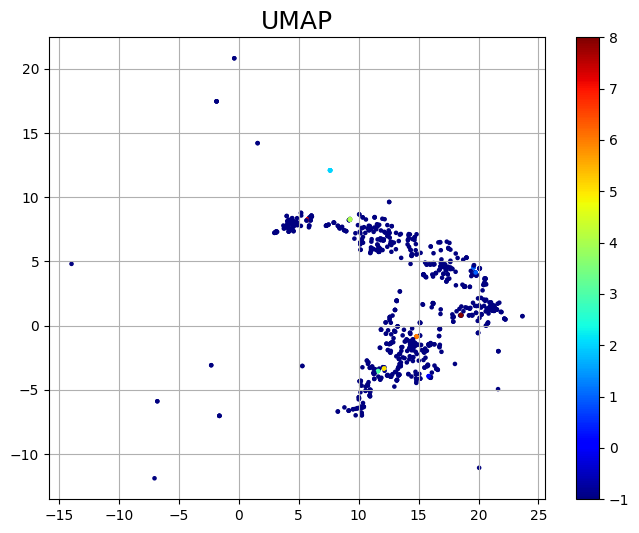

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection[:, 0][:1000], umap_2D_projection[:, 1][:1000], s=5.2, c = colours_opt, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

ANYTHING THAT RELATES TO DBSCAN IS TERRIBLE(Note: This comment may not be deleted under any circumstances)

### Trying sklearns dedicated outlier detection tools:

#### IsolationForest

In [131]:
iso_forest = IsolationForest(max_samples=250, n_estimators=500, max_features=3, random_state=42)
iso_forest.fit(image_pixel_dataframe_norm)
isolated_forest = iso_forest.predict(image_pixel_dataframe_norm)

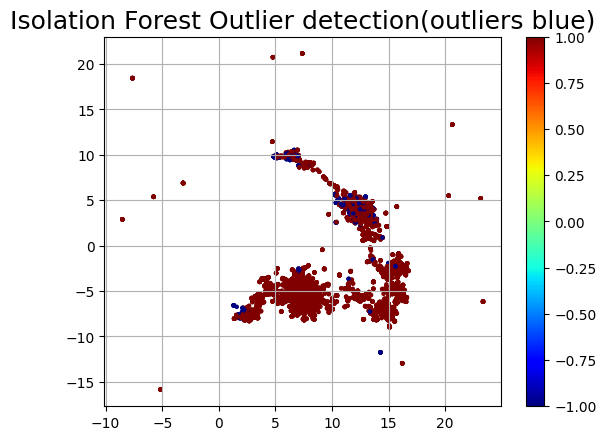

In [132]:
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5.2, c = isolated_forest, cmap="jet")
plt.colorbar()
plt.title("Isolation Forest Outlier detection(outliers blue)", fontsize=18)
plt.grid()
plt.show()

In [139]:
numpy_image_pixel_comp[colours_db == 1].T[-1]

array(['2025-10-03___7_left.webp', '2025-10-18___3_left.webp',
       '2025-10-19___4_right.webp', '2025-11-28___6_right.webp',
       '2025-12-19___0_right.webp', '2025-12-19___1_right.webp',
       '2025-12-19___2_left.webp', '2025-12-19___3_left.webp',
       '2025-12-19___4_left.webp', '2025-12-19___5_left.webp',
       '2025-12-19___6_right.webp', '2025-12-19___7_right.webp',
       '2025-12-19___8_right.webp', '2025-12-19___9_left.webp',
       '2026-03-20___6_left.webp', '2026-04-07___1_left.webp'],
      dtype=object)

#### Local Outlier Factor

In [171]:
factor_algo = LocalOutlierFactor(n_neighbors=10)
factor_algo_results = factor_algo.fit_predict(image_pixel_dataframe_norm)

c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


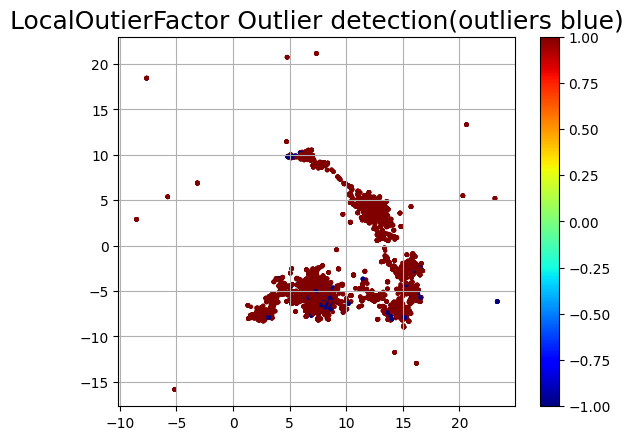

In [172]:
plt.scatter(umap_2D_projection[:, 0], umap_2D_projection[:, 1], s=5.2, c = factor_algo_results, cmap="jet")
plt.colorbar()
plt.title("LocalOutierFactor Outlier detection(outliers blue)", fontsize=18)
plt.grid()
plt.show()

In [179]:
numpy_image_pixel_comp[factor_algo_results == -1].T[-1][210]

'2026-01-19___1_right.webp'

In [176]:
np.argmax(umap_2D_projection[:, 0][factor_algo_results == -1])

np.int64(210)

In [178]:
umap_2D_projection[:, 0][factor_algo_results == -1][210]

np.float32(23.343792)

### Doing stuff with the limited non-image data:


In [46]:
non_image_vars = ["year", "rating", "price", "title", "subtitle", "club", "country"]
low_var_image_pixel = image_pixel_dataframe_no_NaN[non_image_vars]


In [47]:
#Normalizing the data:
image_pixel_low_var_dataframe_norm = pd.DataFrame(preprocessing.normalize(low_var_image_pixel))

In [48]:
image_pixel_low_var_dataframe_norm

,0,1,2,3,4,5,6
0,0.960307,0.012253,0.001235,0.253137,0.000950,0.115408,0.016148
1,0.454341,0.020348,0.002134,0.338678,0.811884,0.138346,0.012577
2,0.829702,0.013336,0.001149,0.274105,0.301598,0.313087,0.217479
3,0.944208,0.037824,0.001588,0.312401,0.000934,0.097129,0.002802
4,0.880691,0.039703,0.002394,0.188502,0.000871,0.432727,0.003918
...,...,...,...,...,...,...,...
7549,0.777798,0.005744,0.001999,0.474061,0.000769,0.412545,0.008074
7550,0.335493,0.004754,0.000563,0.598124,0.000331,0.727784,0.000662
7551,0.279969,0.007732,0.000760,0.499274,0.550680,0.607476,0.002487
7552,0.482353,0.012503,0.003924,0.862129,0.000477,0.154582,0.000954


In [49]:
umap_projector_low_var = umap.UMAP(n_components=2, n_neighbors=50, random_state=42).fit(image_pixel_low_var_dataframe_norm)
umap_2D_projection_low_var = umap_projector_low_var.fit_transform(image_pixel_low_var_dataframe_norm)

c:\Users\Chris\anaconda3\envs\PYTHON313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


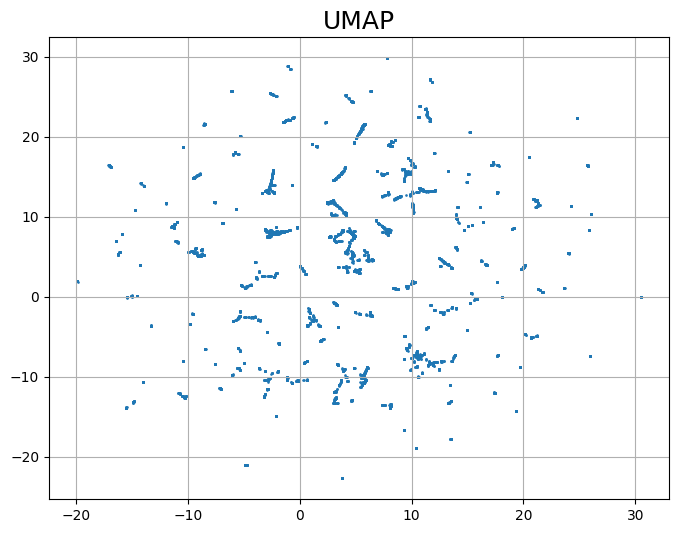

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection_low_var[:, 0], umap_2D_projection_low_var[:, 1], s=0.8)
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

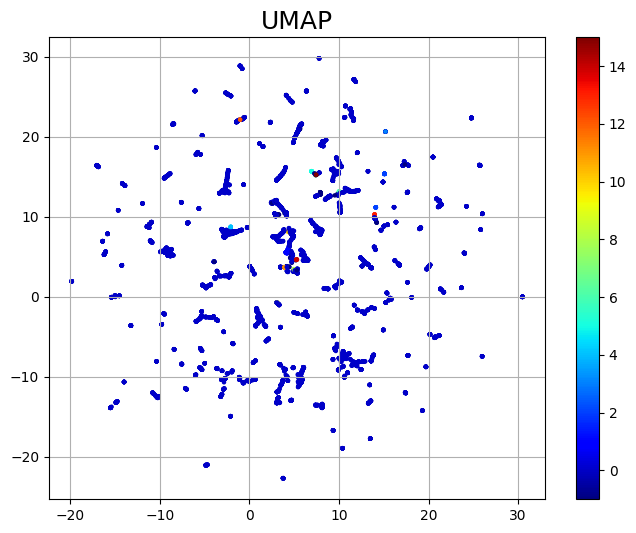

In [55]:
kmeans = cluster.DBSCAN(eps=0.12).fit(image_pixel_low_var_dataframe_norm)
colours = kmeans.labels_
fig, ax = plt.subplots(figsize=(8, 6))
plt.scatter(umap_2D_projection_low_var[:, 0], umap_2D_projection_low_var[:, 1], s=5, c = colours, cmap="jet")
plt.colorbar()
plt.title("UMAP", fontsize=18)
plt.grid()
plt.show()

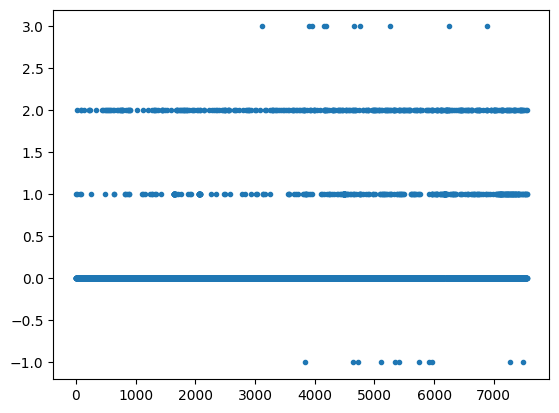

In [27]:
plt.plot(kmeans.labels_, ".")